# CS 415-202501 Homework 1 Question 3: Building and Tuning a CNN for Image Classification

**Objective:** In this assignment, you will design, train, and evaluate a Convolutional Neural Network (CNN) to classify images from the CIFAR-10 dataset. You will experiment with different hyperparameters and regularization techniques to understand their impact on model performance.

## Part 1: Setup and Imports

First, let's import all the necessary libraries and set up our device for training (GPU if available).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---
## Part 2: Load and Visualize the Dataset

We will use the **CIFAR-10** dataset. It consists of 60,000 32x32 color images in 10 classes.

### **Your Task (2a):**
1. Define transformations for both training and test data:

    1.1. Training transforms: Apply data augmentation techniques followed by conversion to PyTorch Tensors and normalization. Include at least:

*   RandomHorizontalFlip with probability 0.5
*   RandomCrop(32, padding=4)
*   One additional augmentation of your choice (e.g., ColorJitter, RandomRotation)
* ToTensor() and Normalize with mean and std of (0.5, 0.5, 0.5) for all three channels

    1.2. Test transforms: Only apply ToTensor() and the same normalization (no augmentation for test data to ensure consistent evaluation)
2.  Load the training and test datasets using `torchvision.datasets.CIFAR10`.
3.  Create `DataLoader`s for both sets. Use a `batch_size` of 64.

In [ ]:
## YOUR CODE HERE ##
# Define transformations

"""
We flip each training image left and right by 50% so that the model does not rely on one direction.
We add a small border and then take a random 32×32 crop to handle small shifts and framing.
We slightly change brightness, contrast, saturation, and a little hue to mimic different lighting. We convert the image to a PyTorch tensor so the model can use it.
Lastly we normalize all three color channels with the same mean and std so values are on a similar scale and training is stable.
"""
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomCrop(32, padding=4),

    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),

    transforms.ToTensor(),

    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


transform_test = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Set batch size
batch_size = 64

# Load training data
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Load test data
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Define the classes
classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

### **Visualize the Data (2b)**
Run the cell below to see a few images and their labels to ensure everything is loaded correctly.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


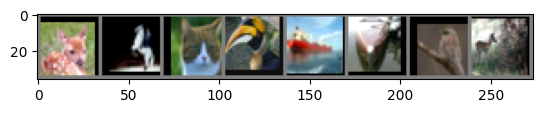

deer  horse cat   bird  ship  ship  bird  deer 


In [ ]:
# Helper function to show an image
def imshow(img):
    img = img / 2 + 0.5     # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
try:
    dataiter = iter(trainloader)
    images, labels = next(dataiter)

    # Show images
    imshow(torchvision.utils.make_grid(images[:8]))
    # Print labels
    print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))
except:
    print("Complete the dataloader in the previous step to visualize the data.")

---
## Part 3: Design the CNN Model

### **Your Task (3a):**
* Complete the `__init__` method by defining the layers for the CNN. A good baseline architecture is:
    1.  A convolutional block: `Conv2d` -> `ReLU` -> `MaxPool2d`
    2.  Another convolutional block: `Conv2d` -> `ReLU` -> `MaxPool2d`
    3.  A fully connected (classifier) block: `Flatten` -> `Linear` -> `ReLU` -> `Dropout` -> `Linear`
    4.  Make the dropout rate a parameter so you can work with different rates.
    5.  Use kernels of size 3x3 and padding.
* Complete the `forward` method to define the data flow through the layers.

In [ ]:
## YOUR CODE HERE ##
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),



            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate the model and print its architecture
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


### **Your Task (3b)**
**3b.1** For your CNN, calculate the number of parameters by using the formula you have seen in class. Show your steps and output. Then, verify your answer by printing out the number of parameters in your model.

**Your answer here...**

In [ ]:
# Verify the number of parameters
total = sum(p.numel() for p in model.parameters())
print("Total params:", total)

Total params: 545098


**3b.2** What would be the number of parameters if the kernel size was 5 instead of 3? Show your calculations.

In [ ]:
"""Conv1 and Conv2 change:
Conv1 (32, K=5): weights 5⋅5⋅3⋅32 = 2,400 5⋅5⋅3⋅32=2,400, bias+32+32 → 2,432
Conv2 (64, K=5): weights 5⋅5⋅32⋅64 = 51,200 5⋅5⋅32⋅64=51,200, bias+64+64 → 51,264
2,432 + 51,264 = 53696

feature map = 64×8×8 = 4096
4096×128 = 524,416

linear output = 128 x 10 = 1280
128×10=1,280

Total: 579,402.
"""

'Conv1 and Conv2 change: \nConv1 (32, K=5): weights 5⋅5⋅3⋅32 = 2,400 5⋅5⋅3⋅32=2,400, bias+32+32 → 2,432\nConv2 (64, K=5): weights 5⋅5⋅32⋅64 = 51,200 5⋅5⋅32⋅64=51,200, bias+64+64 → 51,264\n2,432 + 51,264 = 53696\n\nfeature map = 64×8×8 = 4096\n4096×128 = 524,416 \n\nlinear output = 128 x 10 = 1280\n128×10=1,280\n\nTotal: 579,402.\n'

Your answer here...

**3b.3** What are the dimensions of the output feature map after each layer? Show your calculations.

In [ ]:
"""
Input:32 × 32 ×3

after conv: 32×32×32
maxpool1 = 16×16×32
after conv2 = 16×16×64
maxpool2 = 8×8×64

flatten = 64⋅8⋅8=4096

linear output = 128 and 10 class


3 × 32 × 32   →  32 × 32 ×32     →     32 × 16 × 16       →     64 × 16 × 16 →       64 × 8 × 8    →4096    →   128→10.
"""

'\nInput:32 × 32 ×3 \n\nafter conv: 32×32×32\nmaxpool1 = 16×16×32\nafter conv2 = 16×16×64\nmaxpool2 = 8×8×64\n\nflatten = 64⋅8⋅8=4096\n\nlinear output = 128 and 10 class\n\n\n3 × 32 × 32   →  32 × 32 ×32     →     32 × 16 × 16       →     64 × 16 × 16 →       64 × 8 × 8    →4096    →   128→10.\n'

Your answer here...

---
## Part 4: Define Training and Evaluation Functions

### **Your Task (4):**
1.  **`train_one_epoch`**: Complete the function to perform a single pass of training over the entire dataset.
2.  **`evaluate`**: Complete the function to evaluate the model's performance on the test set. Remember to set the model to evaluation mode and use `torch.no_grad()`.

In [ ]:
## YOUR CODE HERE ##
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    for inputs, labels in dataloader:
        # Move data to the correct device
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Zero the parameter gradients
        optimizer.zero_grad()


        # 2. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 3. Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

def evaluate(model, dataloader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            # 2. Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    accuracy = 100 * correct_predictions / total_samples
    return epoch_loss, accuracy

---
## Part 5: Running the Experiments

### **Your Task (5):**
You will now train and evaluate the model using different hyperparameter configurations. Your goal is to fill the `results` list with the final performance of each configuration.

**Run experiments for at least the following scenarios:**
1.  **Baseline:** Your `SimpleCNN`, `Adam` optimizer with `lr=0.001`, no dropout, no weight decay.
2.  **With Dropout:** Use the baseline model but set a dropout rate (or various rates).
3.  **With Weight Decay:** Use the baseline model but add a weight decay to the Adam optimizer.
4.  **Different Optimizer:** Use the baseline model but switch to a different optimizer.
5.  **Your Own Configurations:** Create and test some new configurations. Try a different learning rate, combine dropout and weight decay, or design a deeper network.

In [ ]:
## YOUR CODE HERE ##

# Define configurations to test
configurations = [
    {
        "name": "Baseline (Adam)",
        "model_params": {"dropout_rate": 0.0},
        "optimizer": "Adam",
        "optimizer_params": {"lr": 0.001, "weight_decay": 0.0}
    },
    {
        "name": "With Dropout",
        "model_params": {"dropout_rate": 0.3},
        "optimizer": "Adam",
        "optimizer_params": {"lr":  0.001, "weight_decay": 0.0}
    },
    {
        "name": "With Weight Decay",
        "model_params": {"dropout_rate": 0.0},
        "optimizer": "Adam",
        "optimizer_params": {"lr":  0.001, "weight_decay": 0.005}
    },
    {
        "name": "Different optimizer",
        "model_params": {"dropout_rate": 0.0},
        "optimizer": "SGD",
        "optimizer_params": {"lr": 0.001, "weight_decay": 0.0}
    },
    {
        "name": "Custom Configuration",
        "model_params": {"dropout_rate": 0.5},
        "optimizer": "Adam",
        "optimizer_params": {"lr": 0.0001, "weight_decay": 0.00005}
    }
    # Add more if necessary
]

print("deneme")

# Store results
results = []
num_epochs = 15 # Train for 15 epochs for each configuration

# Main experiment loop
for config in configurations:
    # Check if the config is a placeholder
    if "model_params" not in config:
        print(f"--- Skipping incomplete configuration: {config['name']} ---\n")
        continue

    print(f"--- Training Configuration: {config['name']} ---")

    # 1. Instantiate model, criterion, and optimizer based on the config
    model = SimpleCNN(**config["model_params"]).to(device)
    criterion = nn.CrossEntropyLoss()
    if config["optimizer"] == "Adam":
        optimizer = optim.Adam(model.parameters(), **config["optimizer_params"])
    elif config["optimizer"] == "SGD":
        optimizer = optim.SGD(model.parameters(), **config["optimizer_params"])

    # 2. Training loop
    for epoch in range(num_epochs):
        # Train for one epoch and evaluate
        train_loss = train_one_epoch(model, trainloader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, testloader, criterion, device)
        print(f"Epoch {epoch+1}/{num_epochs} | Test Acc: {test_acc:.2f}%")

    # 3. Save final results
    final_test_loss, final_test_acc = evaluate(model, testloader, criterion, device)
    results.append({
        "Configuration": config['name'],
        "Final Test Accuracy (%)": final_test_acc
    })
    print(f"--- Finished. Final Accuracy: {final_test_acc:.2f}% ---\n")

--- Training Configuration: Baseline (Adam) ---
Epoch 1/15 | Test Acc: 56.04%
Epoch 2/15 | Test Acc: 62.55%
Epoch 3/15 | Test Acc: 66.55%
Epoch 4/15 | Test Acc: 68.77%
Epoch 5/15 | Test Acc: 69.08%
Epoch 6/15 | Test Acc: 71.82%
Epoch 7/15 | Test Acc: 71.59%
Epoch 8/15 | Test Acc: 73.59%
Epoch 9/15 | Test Acc: 73.37%
Epoch 10/15 | Test Acc: 74.29%
Epoch 11/15 | Test Acc: 74.43%
Epoch 12/15 | Test Acc: 74.87%
Epoch 13/15 | Test Acc: 74.27%
Epoch 14/15 | Test Acc: 75.67%
Epoch 15/15 | Test Acc: 76.40%
--- Finished. Final Accuracy: 76.40% ---

--- Training Configuration: With Dropout ---
Epoch 1/15 | Test Acc: 54.93%
Epoch 2/15 | Test Acc: 59.39%
Epoch 3/15 | Test Acc: 64.14%
Epoch 4/15 | Test Acc: 66.89%
Epoch 5/15 | Test Acc: 68.92%
Epoch 6/15 | Test Acc: 69.29%
Epoch 7/15 | Test Acc: 70.80%
Epoch 8/15 | Test Acc: 71.82%
Epoch 9/15 | Test Acc: 70.91%
Epoch 10/15 | Test Acc: 72.67%
Epoch 11/15 | Test Acc: 73.48%
Epoch 12/15 | Test Acc: 73.48%
Epoch 13/15 | Test Acc: 74.15%
Epoch 14/15 | T

---
## Part 6: Results and Analysis

### **Your Task (6a):**
Run the cell below to display your experimental results in a table.

In [ ]:
if results:
    results_df = pd.DataFrame(results)
    display(results_df.sort_values(by='Final Test Accuracy (%)', ascending=False))
else:
    print("Run the experiments in Part 5 to see the results.")

,Configuration,Final Test Accuracy (%)
0,Baseline (Adam),76.40
1,With Dropout,74.70
2,With Weight Decay,68.02
4,Custom Configuration,60.78
3,Different optimizer,37.10


### **Your Task (6b):**
Write a brief analysis of your results in the text cell below. Address the following questions:
1.  Which configuration performed the best? Why do you think it did?

      **Baseline (Adam) at 76.40% is the winner. Likely because lr=1e-3 with Adam is a well-tuned default for small CNNs on CIFAR-10
      Adam with lr=0.001, no dropout, and no weight decay. It likely won because our model is small and we only trained for 15 epochs, so there isn’t strong overfitting.**

2.  What was the effect of adding dropout? Explain what dropout does.

      **Dropout randomly turns off a portion of the hidden units during training so activations are set to zero on each forward pass. This usually helps when the model is overfitting. In our model adding dropout lowered test accuracy from 76.40% to 74.70%, this is because our model is trained on only 15 epoches. If we have more epoches may be this will work better.**

3.  What was the effect of adding weight decay (L2 regularization)?

      **Weight decay penalizes large weights so the model stays simpler. Here short 15-epoch training is making model underfit. The 0.005 is strong for our 15 epoches CNN, we have a small model and the weight_decay we define is too high for our model. When weights are decreasing, total loss still tries to decrease, but the data loss doesn’t fall enough, and accuracy goes down.**
4.  How did the SGD optimizer compare to Adam?
      **In my runs, Adam did much better than SGD. Accuracy of Adam is 76.4% and accuracy of SDG is 37.1%. This may be because that with this low epoch values and small learning rates, Adam shows better adaptation to data. Adam fits better for short trainings and small models. This model is not suitable for SDG, this doesnt mean SDG is bad. We have to adjust number of epoches, learning rates or even add momentum to SDG to see what happens.**
5.  Based on your findings, what would you try next to improve performance further?

      **The best model Adam is still not perfect, I would increase the number of epoches to reach better accuracy. If we increase number of epoches to 50-100 then model will learn better.
      We can also try different weight decays and dropout values when we increase the epoches.
      Also we can still test SDG, try to make it better. To test SDG better I would change the parameters of SDG optimizer.
      Also we can use type of data precossers like batch normalizations. So that in every step our model will going to be easier to train data, and have higher learning rates.**

*(Double-click here to write your analysis)*

1.  **Best Configuration:** Baseline(Adam)
2.  **Effect of Dropout:** It reduced the accuracy of the model
3.  **Effect of Weight Decay:** It reduced the accuracy of model significantly
4.  **SGD vs. Adam:** Adam wins because model is small and it fits better for Adam optimizer.
5.  **Next Steps:** ...

**1. Baseline (Adam) at 76.40% is the winner. Likely because lr=1e-3 with Adam is a well-tuned default for small CNNs on CIFAR-10 Adam with lr=0.001, no dropout, and no weight decay. It likely won because our model is small and we only trained for 15 epochs, so there isn’t strong overfitting.**


**2. Dropout randomly turns off a portion of the hidden units during training so activations are set to zero on each forward pass. This usually helps when the model is overfitting. In our model adding dropout lowered test accuracy from 76.40% to 74.70%, this is because our model is trained on only 15 epoches. If we have more epoches may be this will work better.**


**3.Weight decay penalizes large weights so the model stays simpler. Here short 15-epoch training is making model underfit. The 0.005 is strong for our 15 epoches CNN, we have a small model and the weight_decay we define is too high for our model. When weights are decreasing, total loss still tries to decrease, but the data loss doesn’t fall enough, and accuracy goes down.**

**4.In my runs, Adam did much better than SGD. Accuracy of Adam is 76.4% and accuracy of SDG is 37.1%. This may be because that with this low epoch values and small learning rates, Adam shows better adaptation to data. Adam fits better for short trainings and small models. This model is not suitable for SDG, this doesnt mean SDG is bad. We have to adjust number of epoches, learning rates or even add momentum to SDG to see what happens.**

**5.The best configuration on Adam optimizer is still not perfect, I would increase the number of epoches to reach better accuracy. If we increase number of epoches to 50-100 then model will learn better. We can also try different weight decays and dropout values when we increase the epoches. Also we can still test SDG, try to make it better. To test SDG better I would change the parameters of SDG optimizer.
Also we can use type of data precossers like batch normalizations. So that in every step our model will going to be easier to train data, and have higher learning rates.**